In [ ]:
!pip install xgboost --quiet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import json
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve, auc
)

try:
    from xgboost import XGBClassifier
    USE_XGBOOST = True
    print('XGBoost available')
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    USE_XGBOOST = False
    print('XGBoost not found — using GradientBoostingClassifier')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Consistent colour palette for 3 risk classes
CLASS_NAMES  = ['Low', 'Moderate', 'High']
CLASS_COLORS = ['#2ecc71', '#f39c12', '#e74c3c']

print('All libraries imported!')

XGBoost available
All libraries imported!


In [4]:
df = pd.read_csv('C:/Users/ALIZA/Downloads/Students Social Media Addiction.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (705, 13)
Columns: ['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score']


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [5]:
print('=== Dataset Overview ===')
print(f'Total records  : {df.shape[0]}')
print(f'Total features : {df.shape[1]}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicates     : {df.duplicated().sum()}')
print(f'\nAddicted_Score range: {df["Addicted_Score"].min()} – {df["Addicted_Score"].max()}')
print(f'\nValue counts:')
print(df['Addicted_Score'].value_counts().sort_index())

=== Dataset Overview ===
Total records  : 705
Total features : 13
Missing values : 0
Duplicates     : 0

Addicted_Score range: 2 – 9

Value counts:
Addicted_Score
2      1
3     16
4     83
5    136
6     61
7    209
8    144
9     55
Name: count, dtype: int64


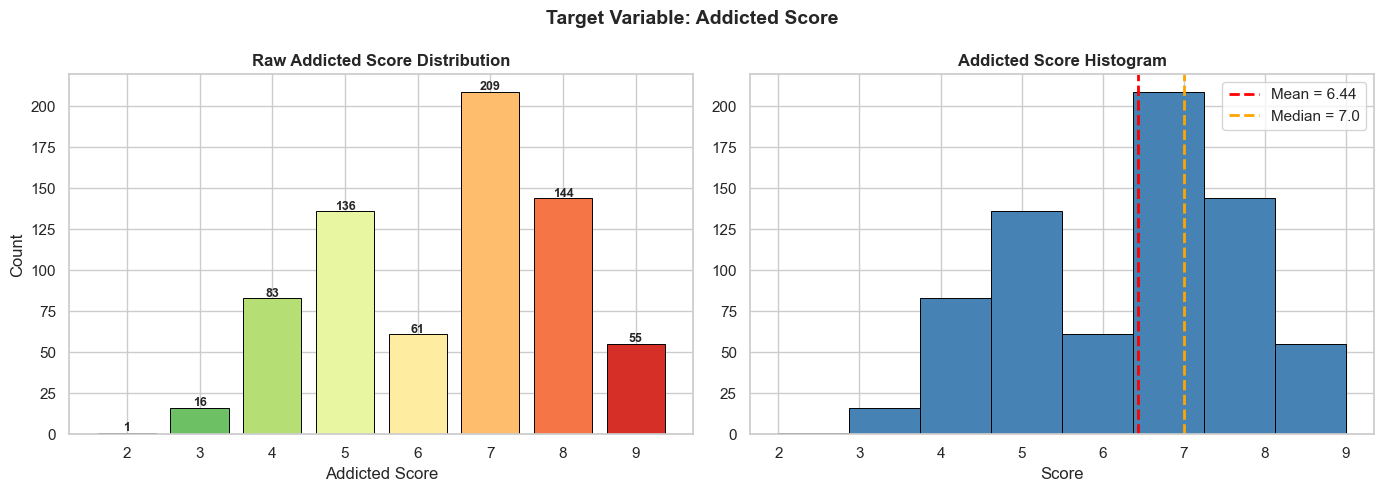

In [6]:
# Addicted Score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Addicted_Score'].value_counts().sort_index()
bar_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(counts)))
axes[0].bar(counts.index.astype(str), counts.values, color=bar_colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Raw Addicted Score Distribution', fontweight='bold')
axes[0].set_xlabel('Addicted Score')
axes[0].set_ylabel('Count')
for i, (score, count) in enumerate(counts.items()):
    axes[0].text(i, count + 1, str(count), ha='center', fontsize=9, fontweight='bold')

axes[1].hist(df['Addicted_Score'], bins=8, color='steelblue', edgecolor='black', linewidth=0.7)
axes[1].axvline(df['Addicted_Score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {df["Addicted_Score"].mean():.2f}')
axes[1].axvline(df['Addicted_Score'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median = {df["Addicted_Score"].median():.1f}')
axes[1].set_title('Addicted Score Histogram', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.suptitle('Target Variable: Addicted Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

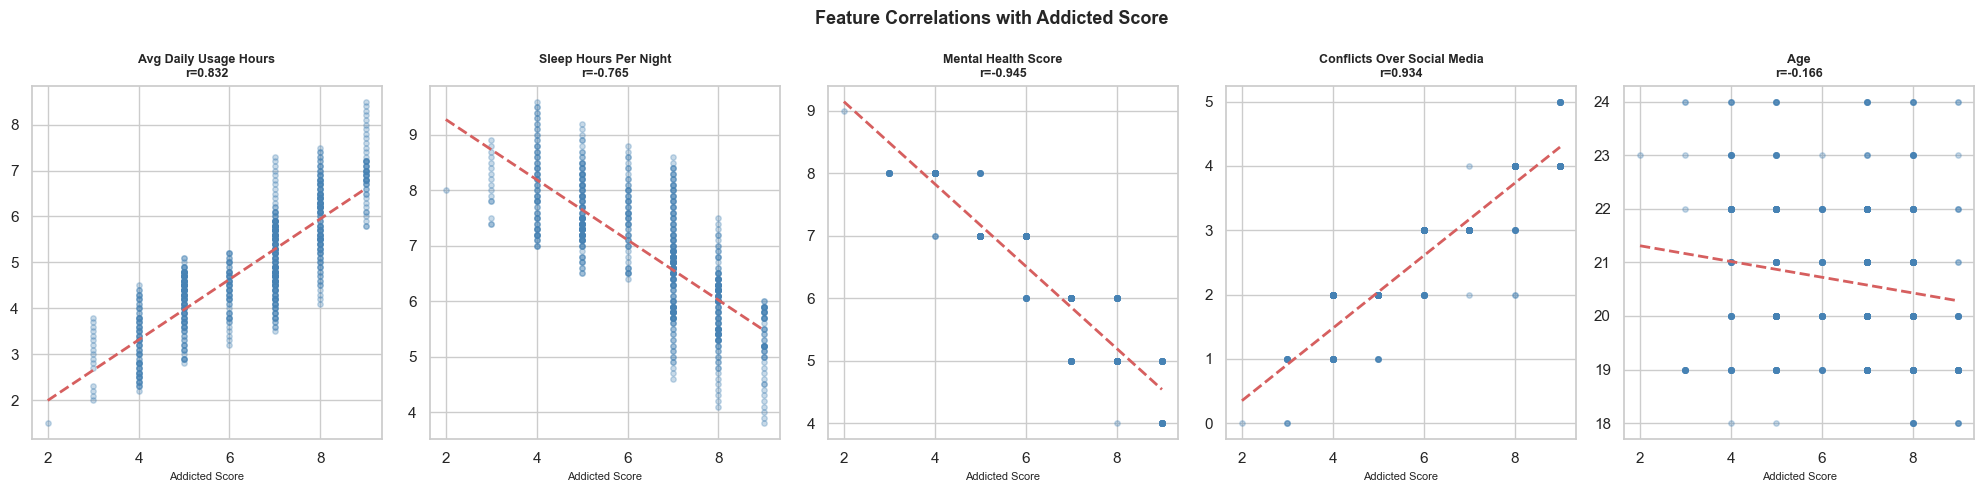

In [7]:
# Key numerical features vs Addicted Score
num_features = ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
                'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Age']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, feat in zip(axes, num_features):
    ax.scatter(df['Addicted_Score'], df[feat], alpha=0.3, color='steelblue', s=15)
    z = np.polyfit(df['Addicted_Score'], df[feat], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df['Addicted_Score'].min(), df['Addicted_Score'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2)
    from scipy.stats import pearsonr
    r, pval = pearsonr(df['Addicted_Score'], df[feat])
    ax.set_title(f'{feat.replace("_"," ")}\nr={r:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Addicted Score', fontsize=8)

plt.suptitle('Feature Correlations with Addicted Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

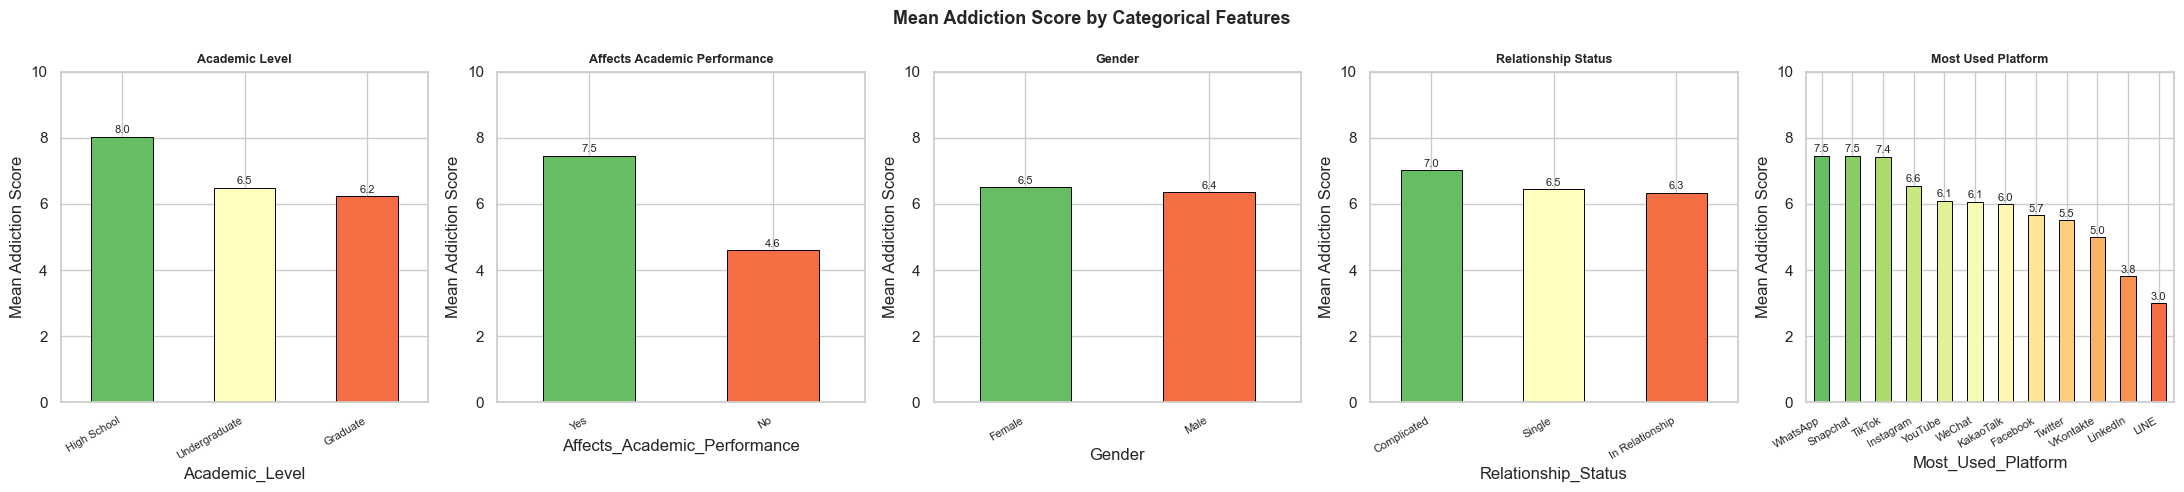

In [8]:
# Categorical features analysis
cat_features = ['Academic_Level', 'Affects_Academic_Performance',
                'Gender', 'Relationship_Status', 'Most_Used_Platform']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, feat in zip(axes, cat_features):
    means = df.groupby(feat)['Addicted_Score'].mean().sort_values(ascending=False)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(means)))
    means.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(feat.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.set_ylabel('Mean Addiction Score')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 10)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height():.1f}', ha='center', fontsize=8)

plt.suptitle('Mean Addiction Score by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

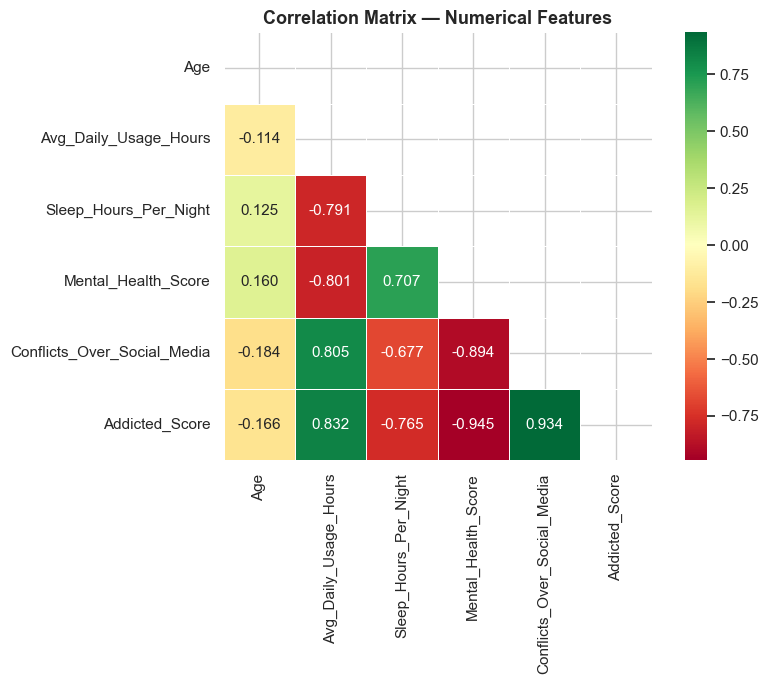

In [9]:
# Correlation heatmap for numerical features
num_cols_plot = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
                 'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']

plt.figure(figsize=(9, 7))
corr = df[num_cols_plot].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True, annot_kws={'size': 11})
plt.title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

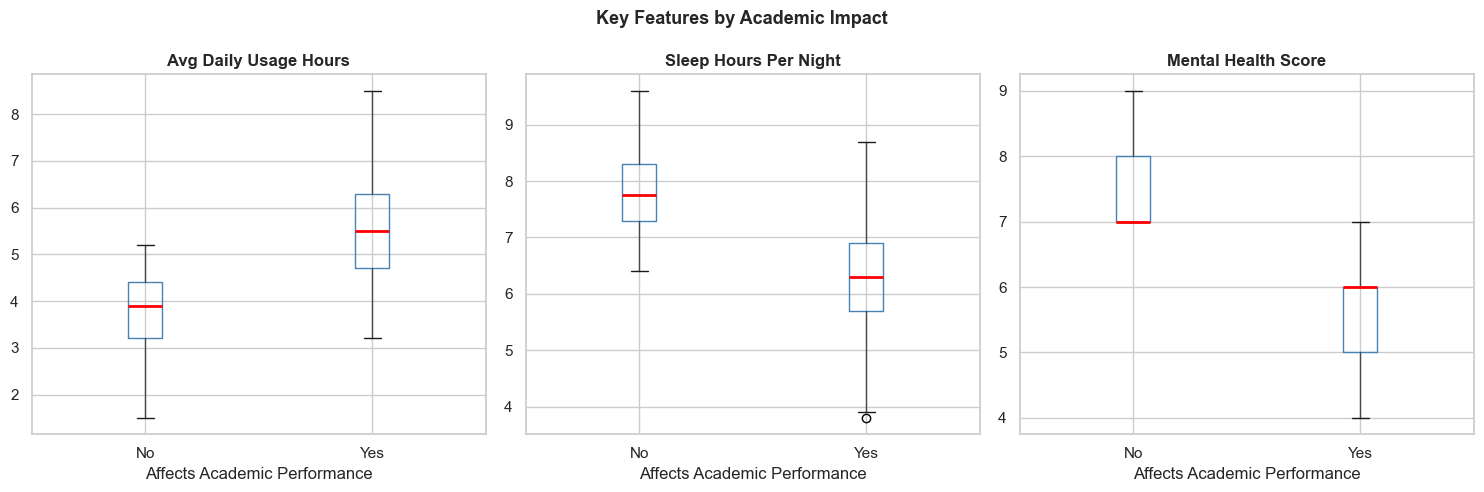

In [10]:
# Boxplots: key features by Affects_Academic_Performance
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']):
    df.boxplot(column=feat, by='Affects_Academic_Performance', ax=ax,
               boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
    ax.set_title(feat.replace('_', ' '), fontweight='bold')
    ax.set_xlabel('Affects Academic Performance')
plt.suptitle('Key Features by Academic Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Risk class distribution:
  Low        (class 0):  100 samples  (14.2%)
  Moderate   (class 1):  197 samples  (27.9%)
  High       (class 2):  408 samples  (57.9%)


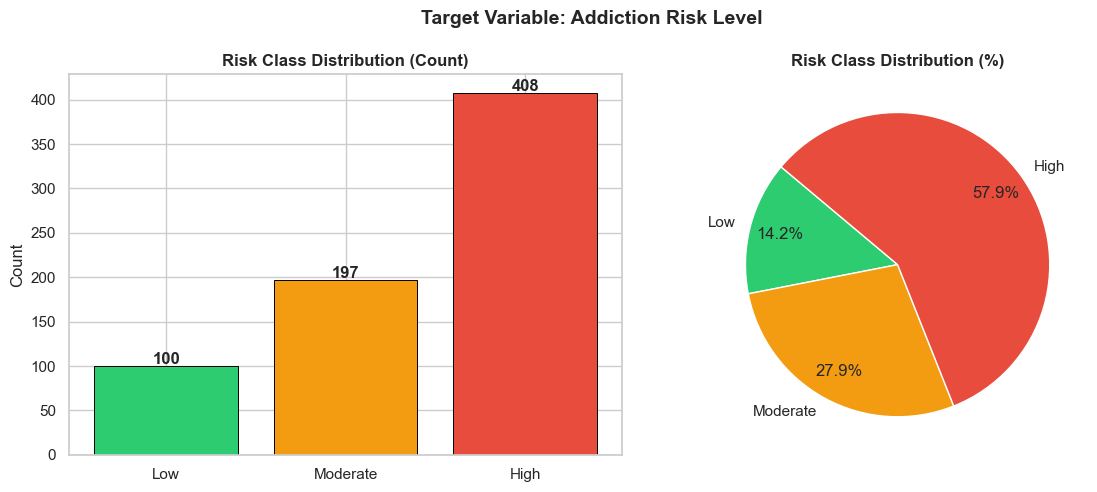

In [11]:
def assign_risk(score):
    if   score <= 4: return 0   # Low
    elif score <= 6: return 1   # Moderate
    else:            return 2   # High

TARGET_MAP     = {'Low': 0, 'Moderate': 1, 'High': 2}
TARGET_MAP_INV = {0: 'Low', 1: 'Moderate', 2: 'High'}

df_model = df.copy()
df_model.drop(columns=['Student_ID', 'Country'], inplace=True)

y = df_model['Addicted_Score'].apply(assign_risk)
X = df_model.drop(columns=['Addicted_Score'])

print('Risk class distribution:')
for k, v in TARGET_MAP_INV.items():
    n = (y == k).sum()
    print(f'  {v:10s} (class {k}): {n:4d} samples  ({n/len(y)*100:.1f}%)')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_counts = y.value_counts().sort_index()
axes[0].bar([TARGET_MAP_INV[i] for i in class_counts.index],
            class_counts.values, color=CLASS_COLORS, edgecolor='black', linewidth=0.7)
axes[0].set_title('Risk Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=[TARGET_MAP_INV[i] for i in class_counts.index],
            colors=CLASS_COLORS, autopct='%1.1f%%', startangle=140, pctdistance=0.8)
axes[1].set_title('Risk Class Distribution (%)', fontweight='bold')

plt.suptitle('Target Variable: Addiction Risk Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('target_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Engineered features
X = X.copy()

# Usage-to-sleep ratio: high value = spending more time on phone than sleeping
X['Usage_Sleep_Ratio'] = X['Avg_Daily_Usage_Hours'] / (X['Sleep_Hours_Per_Night'] + 0.1)

# Combined wellbeing score: low mental health + high conflicts = poor wellbeing
X['Wellbeing_Score'] = X['Mental_Health_Score'] - X['Conflicts_Over_Social_Media']

# Binary: is the student sleeping less than 7 hours (WHO recommended minimum)
X['Sleep_Deprived'] = (X['Sleep_Hours_Per_Night'] < 7).astype(int)

# Binary: heavy user flag (>5 hours daily usage)
X['Heavy_User'] = (X['Avg_Daily_Usage_Hours'] > 5).astype(int)

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols   = X.select_dtypes(include='number').columns.tolist()

print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical features  ({len(numerical_cols)}): {numerical_cols}')
print(f'Total features: {X.shape[1]}')

Categorical features (5): ['Gender', 'Academic_Level', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Relationship_Status']
Numerical features  (9): ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Usage_Sleep_Ratio', 'Wellbeing_Score', 'Sleep_Deprived', 'Heavy_User']
Total features: 14


In [13]:
# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]} samples')
print(f'Test size  : {X_test.shape[0]} samples')
print(f'\nTrain class split:')
for k, v in TARGET_MAP_INV.items():
    print(f'  {v}: {(y_train==k).sum()}')
print(f'\nTest class split:')
for k, v in TARGET_MAP_INV.items():
    print(f'  {v}: {(y_test==k).sum()}')

Train size : 564 samples
Test size  : 141 samples

Train class split:
  Low: 80
  Moderate: 158
  High: 326

Test class split:
  Low: 20
  Moderate: 39
  High: 82


In [14]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=1,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_preds  = rf_pipeline.predict(X_test)
rf_proba  = rf_pipeline.predict_proba(X_test)
rf_acc    = accuracy_score(y_test, rf_preds)
rf_auc    = roc_auc_score(y_test, rf_proba, multi_class='ovr', average='macro')

print(f'Random Forest  =>  Accuracy: {rf_acc:.4f}  |  ROC-AUC: {rf_auc:.4f}')

Random Forest  =>  Accuracy: 0.9645  |  ROC-AUC: 0.9963


In [15]:
if USE_XGBOOST:
    boost_clf   = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
    boost_label = 'XGBoost'
else:
    boost_clf   = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )
    boost_label = 'GradientBoosting'

boost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', boost_clf)
])

boost_pipeline.fit(X_train, y_train)
boost_preds = boost_pipeline.predict(X_test)
boost_proba = boost_pipeline.predict_proba(X_test)
boost_acc   = accuracy_score(y_test, boost_preds)
boost_auc   = roc_auc_score(y_test, boost_proba, multi_class='ovr', average='macro')

print(f'{boost_label:<20} =>  Accuracy: {boost_acc:.4f}  |  ROC-AUC: {boost_auc:.4f}')

XGBoost              =>  Accuracy: 0.9716  |  ROC-AUC: 0.9851


In [16]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced',
        probability=True,   # needed for predict_proba and ROC-AUC
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)
svm_preds = svm_pipeline.predict(X_test)
svm_proba = svm_pipeline.predict_proba(X_test)
svm_acc   = accuracy_score(y_test, svm_preds)
svm_auc   = roc_auc_score(y_test, svm_proba, multi_class='ovr', average='macro')

print(f'SVM (RBF kernel)     =>  Accuracy: {svm_acc:.4f}  |  ROC-AUC: {svm_auc:.4f}')

SVM (RBF kernel)     =>  Accuracy: 0.9929  |  ROC-AUC: 0.9984


In [17]:
# Summary table with cross-validation
results = pd.DataFrame({
    'Model':    ['Random Forest', boost_label, 'SVM (RBF)'],
    'Accuracy': [rf_acc, boost_acc, svm_acc],
    'ROC_AUC':  [rf_auc, boost_auc, svm_auc]
})

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Running 5-fold cross-validation...')
for name, pipe in [('Random Forest', rf_pipeline),
                   (boost_label, boost_pipeline),
                   ('SVM (RBF)', svm_pipeline)]:
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results.loc[results['Model'] == name, 'CV_Mean'] = scores.mean()
    results.loc[results['Model'] == name, 'CV_Std']  = scores.std()
    print(f'  {name:<20} CV scores: {scores.round(4)} => mean={scores.mean():.4f}')

results = results.set_index('Model')
print('\n=== Final Model Performance Summary ===')
print(results.round(4).to_string())

Running 5-fold cross-validation...
  Random Forest        CV scores: [1.     0.9929 0.9787 0.9574 1.    ] => mean=0.9858
  XGBoost              CV scores: [1.     1.     0.9787 0.9574 1.    ] => mean=0.9872
  SVM (RBF)            CV scores: [1.     0.9929 0.9787 0.9787 1.    ] => mean=0.9901

=== Final Model Performance Summary ===
               Accuracy  ROC_AUC  CV_Mean  CV_Std
Model                                            
Random Forest    0.9645   0.9963   0.9858  0.0162
XGBoost          0.9716   0.9851   0.9872  0.0170
SVM (RBF)        0.9929   0.9984   0.9901  0.0096


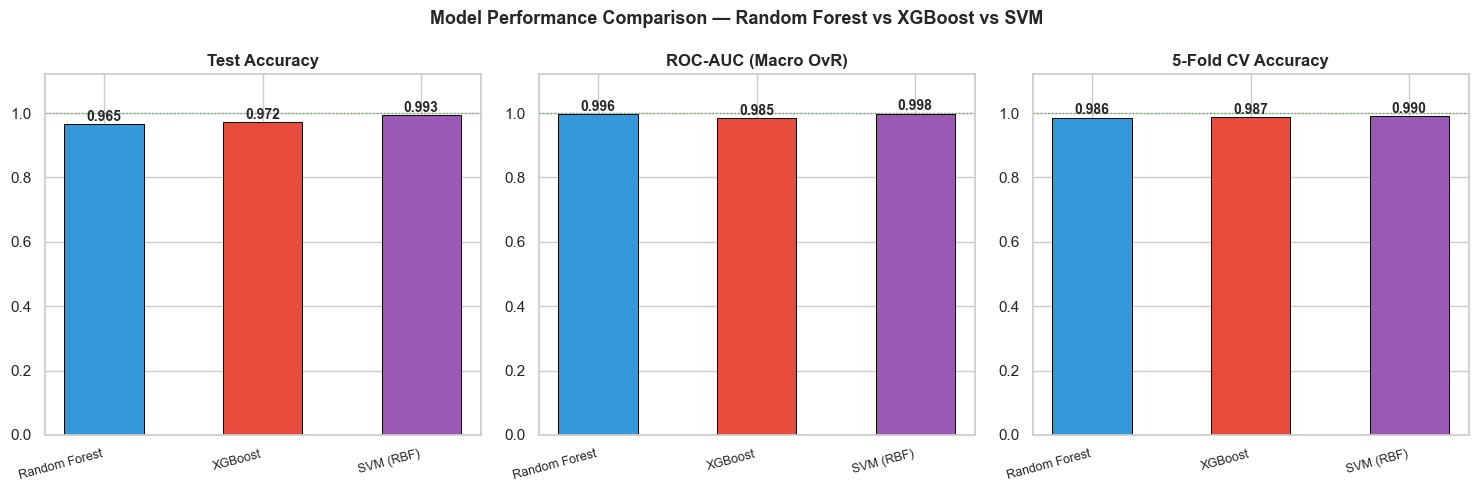

In [18]:
# Bar chart comparison — Accuracy, AUC, CV
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics      = ['Accuracy', 'ROC_AUC', 'CV_Mean']
titles       = ['Test Accuracy', 'ROC-AUC (Macro OvR)', '5-Fold CV Accuracy']
model_colors = ['#3498db', '#e74c3c', '#9b59b6']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(results.index, results[metric],
                  color=model_colors, edgecolor='black', linewidth=0.7, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.set_xticklabels(results.index, rotation=15, ha='right', fontsize=9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.axhline(y=1.0, color='green', linestyle=':', linewidth=1, alpha=0.5)

plt.suptitle('Model Performance Comparison — Random Forest vs XGBoost vs SVM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

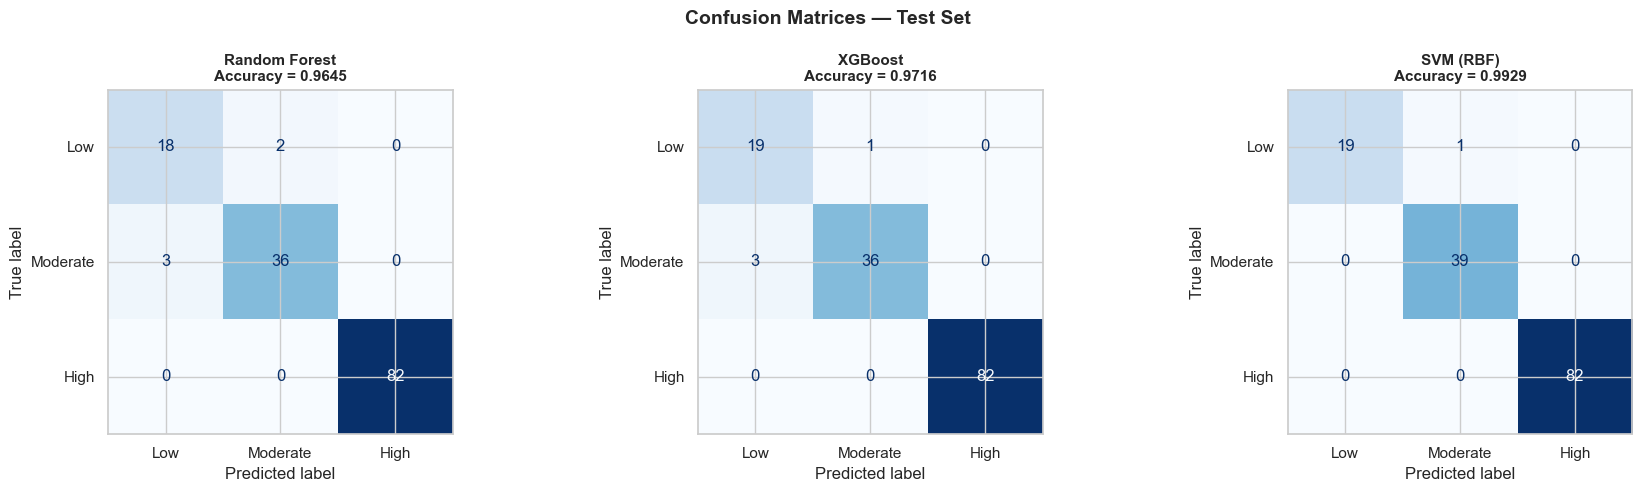

In [19]:
# Confusion matrices — side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds) in zip(axes, [
    ('Random Forest', rf_preds),
    (boost_label, boost_preds),
    ('SVM (RBF)', svm_preds)
]):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc_val = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAccuracy = {acc_val:.4f}', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

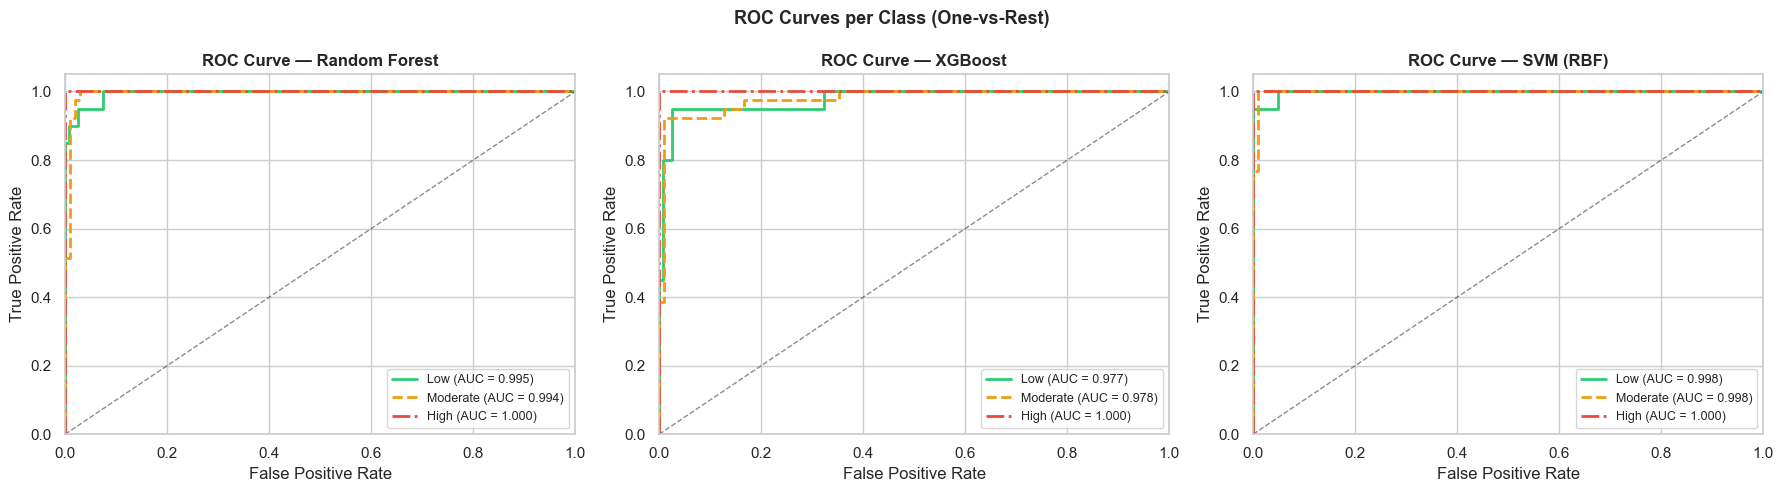

In [20]:
# ROC Curves — one plot per model, one curve per class
y_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
line_styles = ['-', '--', '-.']

for ax, (name, proba) in zip(axes, [
    ('Random Forest', rf_proba),
    (boost_label, boost_proba),
    ('SVM (RBF)', svm_proba)
]):
    for i, (cls, color, ls) in enumerate(zip(CLASS_NAMES, CLASS_COLORS, line_styles)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, linestyle=ls,
                label=f'{cls} (AUC = {roc_auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {name}', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('ROC Curves per Class (One-vs-Rest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Detailed classification reports
for name, preds in [('Random Forest', rf_preds),
                    (boost_label, boost_preds),
                    ('SVM (RBF)', svm_preds)]:
    print(f'\n{"-"*55}')
    print(f'  {name}')
    print('-'*55)
    print(classification_report(y_test, preds, target_names=CLASS_NAMES))


-------------------------------------------------------
  Random Forest
-------------------------------------------------------
              precision    recall  f1-score   support

         Low       0.86      0.90      0.88        20
    Moderate       0.95      0.92      0.94        39
        High       1.00      1.00      1.00        82

    accuracy                           0.96       141
   macro avg       0.93      0.94      0.94       141
weighted avg       0.97      0.96      0.96       141


-------------------------------------------------------
  XGBoost
-------------------------------------------------------
              precision    recall  f1-score   support

         Low       0.86      0.95      0.90        20
    Moderate       0.97      0.92      0.95        39
        High       1.00      1.00      1.00        82

    accuracy                           0.97       141
   macro avg       0.95      0.96      0.95       141
weighted avg       0.97      0.97      0.

In [22]:
best_name = results['ROC_AUC'].idxmax()
pipe_map  = {
    'Random Forest': rf_pipeline,
    boost_label: boost_pipeline,
    'SVM (RBF)': svm_pipeline
}
best_pipeline = pipe_map[best_name]
print(f'Best Model : {best_name}')
print(f'Accuracy   : {results.loc[best_name, "Accuracy"]:.4f}')
print(f'ROC-AUC    : {results.loc[best_name, "ROC_AUC"]:.4f}')
print(f'CV Mean    : {results.loc[best_name, "CV_Mean"]:.4f}')

Best Model : SVM (RBF)
Accuracy   : 0.9929
ROC-AUC    : 0.9984
CV Mean    : 0.9901


In [23]:
# Feature importances (tree-based models only)
best_clf = best_pipeline.named_steps['classifier']
ohe = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + cat_feature_names

if hasattr(best_clf, 'feature_importances_'):
    importances = pd.Series(best_clf.feature_importances_, index=all_feature_names)
    top_n = min(20, len(importances))
    top_feat = importances.nlargest(top_n)

    bar_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top_feat)))
    plt.figure(figsize=(10, 8))
    top_feat.sort_values().plot(kind='barh', color=bar_colors, edgecolor='black', linewidth=0.5)
    plt.title(f'Feature Importances — {best_name}\n(Top {top_n} features)', fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nTop 10 most important features:')
    for feat, imp in importances.nlargest(10).items():
        print(f'  {feat:<40} {imp:.4f}')
else:
    print('SVM selected — feature importances not directly available for SVM.')
    print('Using permutation importance instead would be needed — consider using RF or XGBoost for interpretability.')

SVM selected — feature importances not directly available for SVM.
Using permutation importance instead would be needed — consider using RF or XGBoost for interpretability.


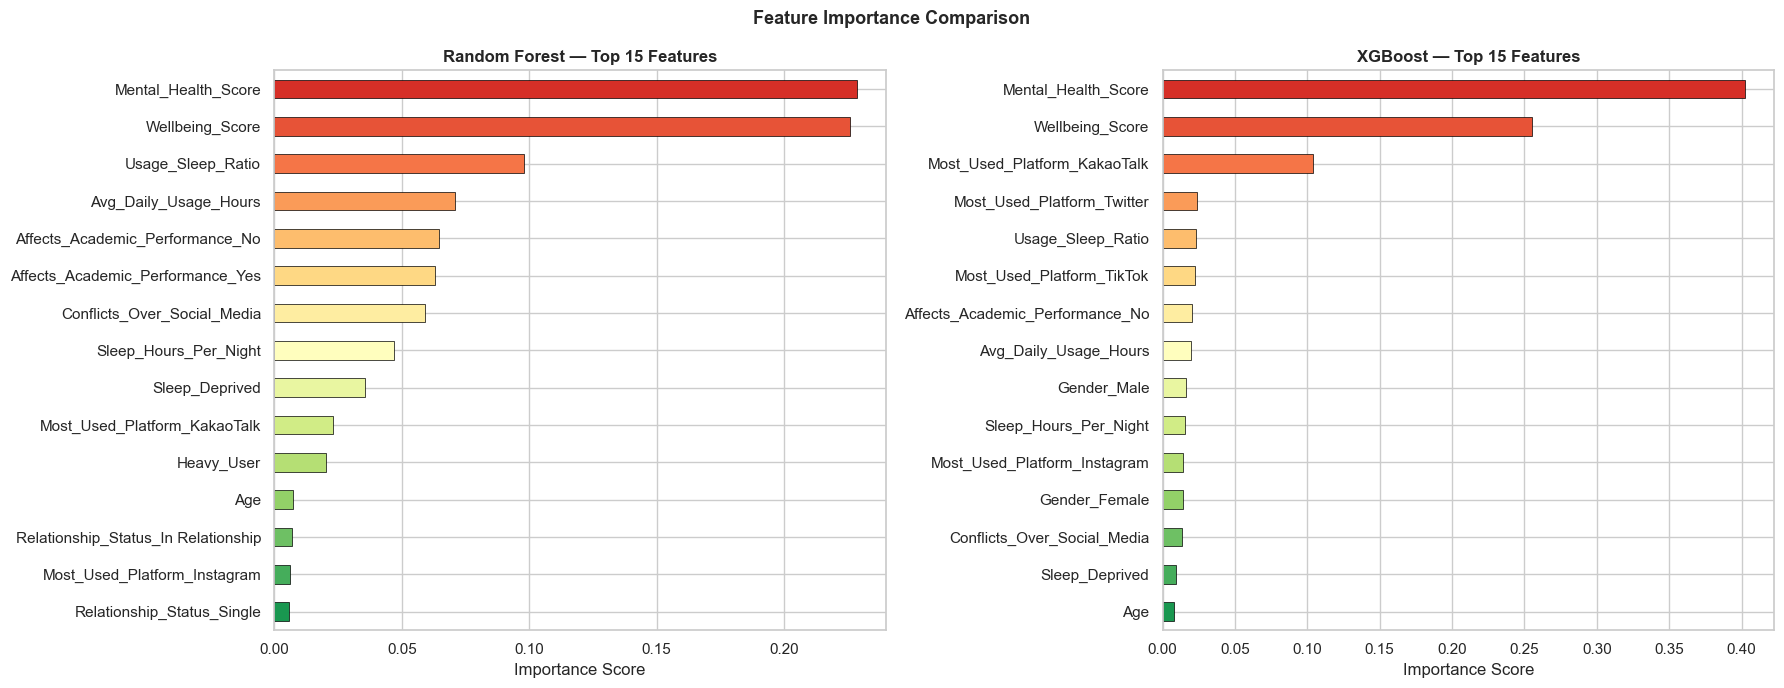

In [24]:
# Feature importance comparison: RF vs XGBoost (both available)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (name, pipe) in zip(axes, [
    ('Random Forest', rf_pipeline),
    (boost_label, boost_pipeline)
]):
    clf = pipe.named_steps['classifier']
    if hasattr(clf, 'feature_importances_'):
        imp = pd.Series(clf.feature_importances_, index=all_feature_names)
        top15 = imp.nlargest(15)
        colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top15)))
        top15.sort_values().plot(kind='barh', ax=ax, color=colors,
                                  edgecolor='black', linewidth=0.5)
        ax.set_title(f'{name} — Top 15 Features', fontweight='bold')
        ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
def predict_addiction_risk(user_data: dict, pipeline=None) -> dict:
    """
    Predict social media addiction risk for a single student.

    Parameters
    ----------
    user_data : dict — feature values (no Student_ID or Country needed)
    pipeline  : trained sklearn Pipeline (defaults to best_pipeline)

    Returns
    -------
    dict with predicted_label, risk_score (0-100), class probabilities (%)
    """
    if pipeline is None:
        pipeline = best_pipeline

    df_u = pd.DataFrame([user_data])

    # Recreate engineered features
    df_u['Usage_Sleep_Ratio'] = df_u['Avg_Daily_Usage_Hours'] / (df_u['Sleep_Hours_Per_Night'] + 0.1)
    df_u['Wellbeing_Score']   = df_u['Mental_Health_Score'] - df_u['Conflicts_Over_Social_Media']
    df_u['Sleep_Deprived']    = (df_u['Sleep_Hours_Per_Night'] < 7).astype(int)
    df_u['Heavy_User']        = (df_u['Avg_Daily_Usage_Hours'] > 5).astype(int)

    proba = pipeline.predict_proba(df_u)[0]
    pred  = pipeline.predict(df_u)[0]
    label = TARGET_MAP_INV[int(pred)]

    # Weighted risk score: Low=0, Moderate=50, High=100
    weights    = np.array([0, 50, 100])
    risk_score = float(np.dot(proba, weights))

    return {
        'predicted_label': label,
        'risk_score':      round(risk_score, 1),
        'probabilities': {
            'Low':      round(float(proba[0]) * 100, 1),
            'Moderate': round(float(proba[1]) * 100, 1),
            'High':     round(float(proba[2]) * 100, 1)
        }
    }

print('Prediction function ready!')

Prediction function ready!


In [26]:
# ── Test with 3 different student profiles ──────────────────────────

profiles = {
    'High-Risk Student': {
        'Age': 19, 'Gender': 'Male', 'Academic_Level': 'Undergraduate',
        'Avg_Daily_Usage_Hours': 7.5, 'Most_Used_Platform': 'TikTok',
        'Affects_Academic_Performance': 'Yes', 'Sleep_Hours_Per_Night': 4.5,
        'Mental_Health_Score': 3, 'Relationship_Status': 'Complicated',
        'Conflicts_Over_Social_Media': 5
    },
    'Moderate-Risk Student': {
        'Age': 21, 'Gender': 'Female', 'Academic_Level': 'Undergraduate',
        'Avg_Daily_Usage_Hours': 4.0, 'Most_Used_Platform': 'Instagram',
        'Affects_Academic_Performance': 'Yes', 'Sleep_Hours_Per_Night': 6.5,
        'Mental_Health_Score': 6, 'Relationship_Status': 'In Relationship',
        'Conflicts_Over_Social_Media': 3
    },
    'Low-Risk Student': {
        'Age': 22, 'Gender': 'Female', 'Academic_Level': 'Graduate',
        'Avg_Daily_Usage_Hours': 1.5, 'Most_Used_Platform': 'LinkedIn',
        'Affects_Academic_Performance': 'No', 'Sleep_Hours_Per_Night': 8.0,
        'Mental_Health_Score': 9, 'Relationship_Status': 'Single',
        'Conflicts_Over_Social_Media': 0
    }
}

for profile_name, profile_data in profiles.items():
    res = predict_addiction_risk(profile_data)
    print(f'=== {profile_name} ===')
    print(f"  Predicted Level : {res['predicted_label']}")
    print(f"  Risk Score      : {res['risk_score']} / 100")
    print(f"  Probabilities   : Low={res['probabilities']['Low']}%  "
          f"Moderate={res['probabilities']['Moderate']}%  "
          f"High={res['probabilities']['High']}%")
    print()

=== High-Risk Student ===
  Predicted Level : High
  Risk Score      : 96.7 / 100
  Probabilities   : Low=0.9%  Moderate=4.9%  High=94.2%

=== Moderate-Risk Student ===
  Predicted Level : High
  Risk Score      : 97.4 / 100
  Probabilities   : Low=0.3%  Moderate=4.7%  High=95.1%

=== Low-Risk Student ===
  Predicted Level : Low
  Risk Score      : 1.9 / 100
  Probabilities   : Low=97.9%  Moderate=0.3%  High=1.8%



In [27]:
os.makedirs('models', exist_ok=True)

joblib.dump(rf_pipeline,    'models/random_forest_pipeline.pkl')
joblib.dump(boost_pipeline, f'models/{boost_label.lower().replace(" ","_")}_pipeline.pkl')
joblib.dump(svm_pipeline,   'models/svm_pipeline.pkl')
joblib.dump(best_pipeline,  'models/best_model_pipeline.pkl')

metadata = {
    'best_model':       best_name,
    'best_accuracy':    round(float(results.loc[best_name, 'Accuracy']), 4),
    'best_auc':         round(float(results.loc[best_name, 'ROC_AUC']),  4),
    'best_cv':          round(float(results.loc[best_name, 'CV_Mean']),  4),
    'all_results':      results.round(4).to_dict(),
    'target_map':       TARGET_MAP,
    'target_map_inv':   {str(k): v for k, v in TARGET_MAP_INV.items()},
    'risk_score_bins':  {'Low': '2-4', 'Moderate': '5-6', 'High': '7-9'},
    'numerical_cols':   numerical_cols,
    'categorical_cols': categorical_cols,
    'feature_order':    X.columns.tolist()
}
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('All models saved to ./models/')
print('Files:', sorted(os.listdir('models')))

All models saved to ./models/
Files: ['best_model_pipeline.pkl', 'metadata.json', 'random_forest_pipeline.pkl', 'svm_pipeline.pkl', 'xgboost_pipeline.pkl']


In [29]:
print('=' * 65)
print('    SOCIAL MEDIA ADDICTION RISK MODEL  —  FINAL SUMMARY')
print('=' * 65)
print(f'  Dataset          : 705 students × 11 features (after drop)')
print(f'  Task             : 3-class risk classification')
print(f'  Classes          : Low (score 2-4) | Moderate (5-6) | High (7-9)')
print(f'  Train / Test     : 80% / 20%  (stratified split)')
print(f'  Engineered Feats : 4 new features added')
print('-' * 65)
for model_name in results.index:
    acc = results.loc[model_name, 'Accuracy']
    auc_val = results.loc[model_name, 'ROC_AUC']
    cv  = results.loc[model_name, 'CV_Mean']
    std = results.loc[model_name, 'CV_Std']
    tag = '  <-- BEST' if model_name == best_name else ''
    print(f'  {model_name:<22}  Acc={acc:.3f}  AUC={auc_val:.3f}  CV={cv:.3f}±{std:.3f}{tag}')
print('=' * 65)
print(f'  Best Model       : {best_name}')
print(f'  Models saved to  : ./models/')
print('=' * 65)

    SOCIAL MEDIA ADDICTION RISK MODEL  —  FINAL SUMMARY
  Dataset          : 705 students × 11 features (after drop)
  Task             : 3-class risk classification
  Classes          : Low (score 2-4) | Moderate (5-6) | High (7-9)
  Train / Test     : 80% / 20%  (stratified split)
  Engineered Feats : 4 new features added
-----------------------------------------------------------------
  Random Forest           Acc=0.965  AUC=0.996  CV=0.986±0.016
  XGBoost                 Acc=0.972  AUC=0.985  CV=0.987±0.017
  SVM (RBF)               Acc=0.993  AUC=0.998  CV=0.990±0.010  <-- BEST
  Best Model       : SVM (RBF)
  Models saved to  : ./models/
